### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 3
### Due: Wednesday, Sep. 30 at 11.59pm CST
---

## Only one problem this week

This problem uses a dataset in `/coursework/homeworks/hw_data/`.

1) Read in `hw3_data_1.npy`. This is a (50 x 2) numpy array, with measurements in the first column and uncertainties in the second column. Using the analytic results for heteroscedastic Gaussian data from lectures, compute the sample mean and the standard error on the sample mean from for this data.

2) Reusing some approaches and tools from `Lecture_6`, write a ln-likelihood function for heteroscedastic Gaussian data, and use it in a fitting algorithm to find the best-fit mean. *Remember that scipy optimizers are set up to minimize functions.*

3) Using the same numerical technique from `Lecture_5`, compute the Fisher uncertainty estimate on the mean.

4) Using the bootstrap method, generate $1000$ bootstrap realizations of this dataset. *DO NOT use the `astroML` code. Write your own bootstrap function from scratch. Also recall that when resampling data, measurements and uncertainties should stay paired together.*

5) Repeat (2) with all $1000$ boostrap datasets to find the distribution of the sample mean. Plot a normalized histogram of these bootstrap means, and overplot a Gaussian pdf with the mean and std found in (1). Do these agree?

6) While we have fitted a heteroscedastic Gaussian to this data, let's try something else. Write some code to define a ln-likelihood for a Laplace distribution evaluated on this data. Fit simultaneously for the Laplace location parameter $\mu$ and scale parameter $\Delta$.

7) Compute the AIC values for the heteroscedastic Gaussian model and the Laplacian model. Which model is favored by the data?

8) Using the $1000$ bootstrap datasets from before, fit for the Laplacian $\mu$ and $\Delta$ for each. Make a nice `corner` plot of the distributions of $\mu$ and $\Delta$ that shows both the marginal $1$D distributions and the joint $2$D distribution. Make sure the plot has labels, shows the titles on each $1$D marginal panel, and has $68\%$ and $95\%$ levels.

9) Let's finish with a Fisher uncertainty estimate of the Laplacian parameters. Use the following code to install `numdifftools` which provides a simple way to compute derivatives. We can then compute the Hessian matrix, which is the matrix of the second derivatives of the user's function. This should be computed at the best-fit Laplacian parameters $\mu$ and $\Delta$. To finish, invert the matrix, and then take the square root. The diagonal entries will then be the Fisher uncertainties on $\mu$ and $\Delta$. How does these compare to the bootstrap distribution widths found in (8)?

In [9]:
!pip install numdifftools

In [10]:
import numdifftools as nd
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.linalg.inv(H)**0.5

NameError: name 'f_lnlaplace' is not defined

### Solution

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

data_path = r"C:\Users\jolee\Documents\astrostats_ttu_fall26\coursework\homeworks\hw_data\hw3_data_1.npy"

# Load the data.
# Column 0 contains the measurements.
# Column 1 contains the uncertainties.
data = np.load(data_path)

# Separate the two columns.
x = data[:, 0]
sigma = data[:, 1]

# Each measurement is weighted by the inverse of its variance.
weights = 1 / sigma**2

# Calculate the weighted sample mean.
mu = np.sum(weights * x) / np.sum(weights)

# Calculate the standard error on the weighted mean.
sigma_mu = 1 / np.sqrt(np.sum(weights))

print("Weighted mean =", mu)
print("Standard error =", sigma_mu)

Weighted mean = 3.917992034606056
Standard error = 0.09481084100510956


In [2]:
def f_lngauss(beta):
    # The optimizer passes the parameters as an array. Our only free parameter is the Gaussian mean, mu.
    mu = beta[0]

    # Calculate the negative log-likelihood for the data.
    # The Gaussian likelihood for each measurement includes:
    #   (x_i - mu)^2 / sigma_i^2
    # and the normalization term:
    #   ln(2*pi*sigma_i^2)
    # We use the negative log-likelihood because scipy's minimize() function is designed to minimize a function.
    return 0.5 * np.sum(
        ((x - mu) / sigma)**2
        + np.log(2 * np.pi * sigma**2)
    )


# Use the analytic weighted mean from part 1 as our initial guess.
beta_start = [mu]

# Find the value of mu that minimizes the negative log-likelihood.
beta_gauss = minimize(f_lngauss, beta_start)

# Extract the best-fit mean from the result.
mu_gauss = beta_gauss.x[0]

print("Best-fit Gaussian mean =", mu_gauss)

Best-fit Gaussian mean = 3.917992034606056


In [12]:
# For the heteroscedastic Gaussian model, the Fisher uncertainty on the mean has the same analytic form as the standard error calculated in Part 1.
fisher_mu = 1 / np.sqrt(np.sum(1 / sigma**2))

print("Fisher uncertainty on mu =", fisher_mu)

Fisher uncertainty on mu = 0.09481084100510956


In [13]:
def bootstrap(data, n_bootstrap=1000):
    # Number of measurements in the original dataset.
    n = len(data)

    # This list will store all of our bootstrap datasets.
    bootstrap_samples = []

    # Generate the requested number of bootstrap realizations.
    for i in range(n_bootstrap):

        # Randomly choose n indices from the original dataset.
        # Sampling is done with replacement, which is what makes this a bootstrap sample.
        indices = np.random.randint(0, n, n)

        # Select entire rows rather than selecting the two columns independently. This keeps each measurement paired with its corresponding uncertainty.
        sample = data[indices]

        # Save this bootstrap dataset.
        bootstrap_samples.append(sample)

    # Convert the list into a NumPy array for easier processing later.
    return np.array(bootstrap_samples)


# Generate 1000 bootstrap realizations of the original dataset.
bootstrap_data = bootstrap(data, 1000)

print("Bootstrap array shape:", bootstrap_data.shape)

Bootstrap array shape: (1000, 100, 2)


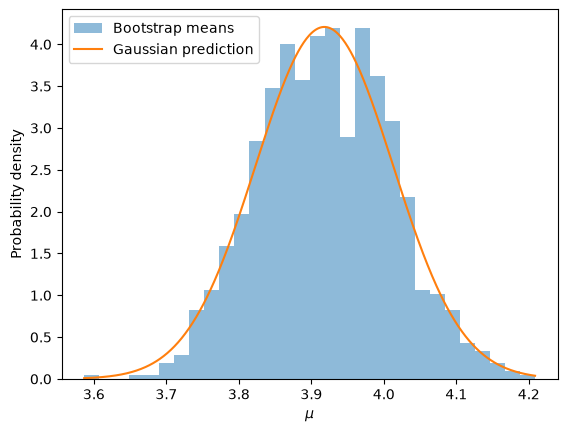

Mean of bootstrap means = 3.9200782534404572
Std of bootstrap means = 0.09176220046017133


In [14]:
# This list will contain the best-fit mean from each bootstrap dataset.
bootstrap_means = []

# Loop over all 1000 bootstrap datasets.
for sample in bootstrap_data:

    # Separate the measurements and uncertainties for this particular bootstrap realization.
    x_boot = sample[:, 0]
    sigma_boot = sample[:, 1]

    # Calculate the weighted mean for this bootstrap dataset. This is the same analytic Gaussian result used in Part 1.
    weights_boot = 1 / sigma_boot**2
    mu_boot = np.sum(weights_boot * x_boot) / np.sum(weights_boot)

    # Store the fitted mean.
    bootstrap_means.append(mu_boot)

# Convert the list into a NumPy array.
bootstrap_means = np.array(bootstrap_means)


# Create a normalized histogram of the bootstrap means.
# density=True makes the histogram integrate to approximately 1, allowing us to compare it directly with a probability density.
plt.hist(
    bootstrap_means,
    bins=30,
    density=True,
    alpha=0.5,
    label="Bootstrap means"
)


# Create x-values covering the range of the bootstrap distribution.
x_plot = np.linspace(
    bootstrap_means.min(),
    bootstrap_means.max(),
    500
)

# Construct a Gaussian PDF using the analytic mean and standard error from Part 1.
gaussian_pdf = (
    1 / (sigma_mu * np.sqrt(2 * np.pi))
    * np.exp(
        -0.5 * ((x_plot - mu) / sigma_mu)**2
    )
)

# Plot the Gaussian prediction over the bootstrap histogram.
plt.plot(
    x_plot,
    gaussian_pdf,
    label="Gaussian prediction"
)

plt.xlabel(r"$\mu$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

print("Mean of bootstrap means =", np.mean(bootstrap_means))
print("Std of bootstrap means =", np.std(bootstrap_means))

In [15]:
def f_lnlaplace(beta):
    # The two parameters we are fitting are:
    # beta[0] = mu      -> location parameter
    # beta[1] = Delta   -> scale parameter
    mu = beta[0]
    Delta = beta[1]

    # Delta must be positive because it represents a scale.
    # If the optimizer tries a non-positive value, return infinity so that this parameter value cannot be selected.
    if Delta <= 0:
        return np.inf

    # Negative log-likelihood for the Laplace distribution:
    #
    #   -ln(L) = sum[ ln(2*Delta) + |x_i - mu| / Delta ]
    #
    # We minimize the negative log-likelihood to find the maximum-likelihood values of mu and Delta.
    return np.sum(
        np.log(2 * Delta)
        + np.abs(x - mu) / Delta
    )


# Use the median as a reasonable starting guess for the
# Laplace location parameter.
mu_start = np.median(x)

# The mean absolute deviation from the median gives a reasonable initial guess for the Laplace scale.
Delta_start = np.mean(np.abs(x - mu_start))


# Fit both mu and Delta simultaneously.
beta_laplace = minimize(
    f_lnlaplace,
    [mu_start, Delta_start],
    bounds=[
        (None, None),  # mu can be any real number
        (1e-10, None)  # Delta must remain positive
    ]
)

# Extract the best-fit parameters.
mu_laplace = beta_laplace.x[0]
Delta_laplace = beta_laplace.x[1]

print("Best-fit Laplace mu =", mu_laplace)
print("Best-fit Laplace Delta =", Delta_laplace)

Best-fit Laplace mu = 4.085141264538312
Best-fit Laplace Delta = 0.8822692311710573


In [16]:
# Number of fitted parameters in each model.
# Gaussian: only mu
k_gauss = 1

# Laplace: mu and Delta
k_laplace = 2


# beta_gauss contains the best-fit Gaussian parameter.
# beta_gauss.fun is the minimized negative log-likelihood.
aic_gauss = 2 * k_gauss + 2 * beta_gauss.fun


# beta_laplace contains the best-fit Laplace parameters.
# beta_laplace.fun is the minimized negative log-likelihood.
aic_laplace = 2 * k_laplace + 2 * beta_laplace.fun


print("Gaussian AIC =", aic_gauss)
print("Laplace AIC =", aic_laplace)

Gaussian AIC = 296.5157257746175
Laplace AIC = 317.57783235318016


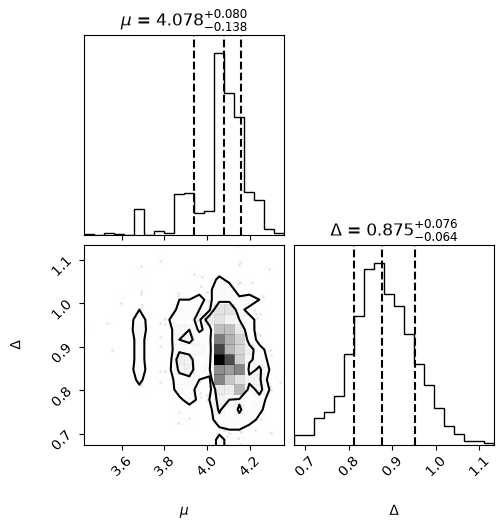

In [17]:
# This list will store the fitted [mu, Delta] pair
# from each bootstrap realization.
bootstrap_laplace = []


# Fit the Laplace model to every bootstrap dataset.
for sample in bootstrap_data:

    # Extract the measurements from this bootstrap sample.
    x_boot = sample[:, 0]

    # Define the Laplace negative log-likelihood specifically for this bootstrap dataset.
    def f_laplace_boot(beta):

        # Extract the two parameters being fitted.
        mu_boot = beta[0]
        Delta_boot = beta[1]

        # Delta must be positive.
        if Delta_boot <= 0:
            return np.inf

        # Calculate the negative log-likelihood for this particular bootstrap sample.
        return np.sum(
            np.log(2 * Delta_boot)
            + np.abs(x_boot - mu_boot) / Delta_boot
        )


    # Use the median and mean absolute deviation as starting guesses.
    mu_start_boot = np.median(x_boot)
    Delta_start_boot = np.mean(
        np.abs(x_boot - mu_start_boot)
    )


    # Fit mu and Delta simultaneously.
    result = minimize(
        f_laplace_boot,
        [mu_start_boot, Delta_start_boot],
        bounds=[
            (None, None),
            (1e-10, None)
        ]
    )

    # Save the best-fit parameters from this bootstrap sample.
    bootstrap_laplace.append(result.x)


# Convert the results to a NumPy array.
bootstrap_laplace = np.array(bootstrap_laplace)

# Separate the two parameter distributions.
mu_boot_laplace = bootstrap_laplace[:, 0]
Delta_boot_laplace = bootstrap_laplace[:, 1]

import corner

# Combine the two parameter distributions into one array.
# Each row corresponds to one bootstrap realization:[mu, Delta]
samples = np.column_stack([
    mu_boot_laplace,
    Delta_boot_laplace
])


# Make the corner plot.
figure = corner.corner(
    samples,

    # Label the two parameters.
    labels=[
        r"$\mu$",
        r"$\Delta$"
    ],

    # Display the parameter values in the titles of the 1D marginal distributions.
    show_titles=True,

    # Control the number of decimal places in those titles.
    title_fmt=".3f",

    # Show the 68% and 95% confidence/credible regions in the 2D distribution.
    levels=[
        0.68,
        0.95
    ],

    # Display the 16th, 50th, and 84th percentiles on the 1D marginal distributions.
    quantiles=[
        0.16,
        0.50,
        0.84
    ]
)

plt.show()

In [20]:
!pip install numdifftools

import numdifftools as nd
# Calculate the Hessian matrix of the Laplace negative log-likelihood at the best-fit values of mu and Delta.
# The Hessian contains the second derivatives:
#       [ d²f/dmu²       d²f/dmu dDelta ]
# H  =  [                          ]
#       [ d²f/dDelta dmu  d²f/dDelta²  ]
H = nd.Hessian(f_lnlaplace)(
    [beta_laplace.x[0], beta_laplace.x[1]]
)

print("Hessian matrix:")
print(H)


# The inverse Hessian gives the covariance matrix
# associated with the fitted parameters.
cov_laplace = np.linalg.inv(H)

print("Covariance matrix:")
print(cov_laplace)


# The diagonal elements of the covariance matrix are the variances of mu and Delta.
# Taking the square root gives the corresponding 1-sigma Fisher uncertainties.
sigma_laplace = np.sqrt(np.diag(cov_laplace))

print("Fisher uncertainty on mu =", sigma_laplace[0])
print("Fisher uncertainty on Delta =", sigma_laplace[1])


print("Bootstrap std of mu =", np.std(mu_boot_laplace))
print("Fisher uncertainty of mu =", sigma_laplace[0])

print("Bootstrap std of Delta =", np.std(Delta_boot_laplace))
print("Fisher uncertainty of Delta =", sigma_laplace[1])

Hessian matrix:
[[ 8.38218933e+01 -3.29388719e-03]
 [-3.29388719e-03  1.28468819e+02]]
Covariance matrix:
[[1.19300574e-02 3.05881719e-07]
 [3.05881719e-07 7.78398997e-03]]
Fisher uncertainty on mu = 0.10922480223744976
Fisher uncertainty on Delta = 0.08822692316146458
Bootstrap std of mu = 0.12649089864235402
Fisher uncertainty of mu = 0.10922480223744976
Bootstrap std of Delta = 0.0723523452652101
Fisher uncertainty of Delta = 0.08822692316146458


<span style="color:red">NP: and how do these uncertainties compare? -1 pt </span>